# Congressional Voting Dataset

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

## EDA

In [21]:
congress_df_train = pd.read_csv("data/congressional-voting/CongressionalVotingID.shuf.lrn.csv")
congress_df_train.drop(columns=['ID'], inplace=True)

In [22]:
congress_df_train.info()
for i in congress_df_train.columns:
    print(congress_df_train[i].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   class                                   218 non-null    object
 1   handicapped-infants                     218 non-null    object
 2   water-project-cost-sharing              218 non-null    object
 3   adoption-of-the-budget-resolution       218 non-null    object
 4   physician-fee-freeze                    218 non-null    object
 5   el-salvador-aid                         218 non-null    object
 6   religious-groups-in-schools             218 non-null    object
 7   anti-satellite-test-ban                 218 non-null    object
 8   aid-to-nicaraguan-contras               218 non-null    object
 9   mx-missile                              218 non-null    object
 10  immigration                             218 non-null    object
 11  synfue

## Preprocessing

1. Drop ID column
2. Label encode everything else

> Note: 
    unique values are 'y', 'n', 'unknown'. For decision tree and random forest dataset after step 1 is also feasible but for knn we need to encode 'unknown' as 0.5, so that 'unknown' distance from  'y' and 'n' is equal and the information the the person abstaining to answer is preserved.

In [23]:
congress_df_train.head()

,class,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-crporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,democrat,y,n,y,n,y,y,y,n,y,y,n,n,y,y,n,unknown
1,democrat,n,n,y,n,y,y,n,n,n,y,y,y,y,y,n,y
2,democrat,y,n,y,n,n,n,y,y,y,n,n,n,n,n,y,unknown
3,republican,n,n,n,y,y,n,n,n,n,n,n,y,n,y,unknown,y
4,democrat,y,y,y,n,n,y,unknown,y,y,n,y,n,y,n,y,y


### Custom Label Encoding

In [24]:
mapping_X = {
    'y': 1, 
    'unknown': 0.5,
    'n': 0
    }

mapping_y = {
    'democrat': 1,
    'republican': 0
    }

X = congress_df_train.drop(columns=['class'])
X_encoded = X.apply(lambda col: col.map(mapping_X))

y_encoded = congress_df_train['class'].map(mapping_y)

# combine and export to csv
congress_preprocessed = pd.concat([X_encoded, y_encoded], axis=1)
congress_preprocessed.to_csv("data/congressional-voting/congressional_voting_preprocessed.csv", index=False)


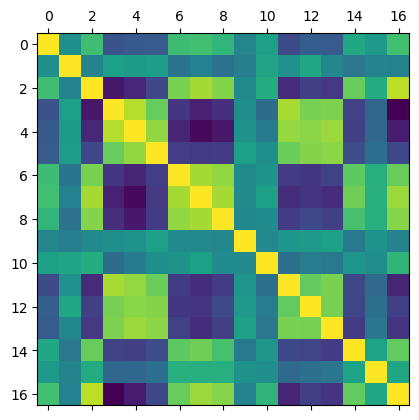

In [26]:
plt.matshow(congress_preprocessed.corr())
plt.show()

# Testing

In [ ]:
congress_df_test = pd.read_csv("data/congressional-voting/CongressionalVotingID.shuf.tes.csv")